# Logistisk Regression — Diamond Prices

## Vad är Logistisk Regression?
Logistisk Regression är vår **basmodell (baseline)**.
Den är enkel, snabb och tolkbar — perfekt som första modell
att jämföra övriga modeller mot.

Till skillnad från Linjär Regression förutsäger den inte ett
kontinuerligt värde utan **sannolikheten** för ett binärt utfall:

- **0 = Billig diamant** (pris under medianen $2,401)
- **1 = Dyr diamant** (pris över medianen $2,401)

## Vad undersöker vi i denna notebook?
1. Träna en Logistisk Regression på diamond-data
2. Utvärdera med Confusion Matrix, Classification Report och ROC AUC
3. Undersöka vilka features som påverkar modellen mest
4. Undersöka vad som händer när vi tar bort x, y, z
   (de multikollineära variablerna vi hittade i EDA)

## Hypotes
Baserat på EDA förväntar vi oss:
- Hög accuracy eftersom carat korrelerar starkt med price (0.92)
- x, y, z bidrar troligen med redundant information
- Modellen bör prestera bra även utan x, y, z

In [1]:
# ── Imports ────────────────────────────────────────────────────────────────────
import sys
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import accuracy_score

# Lägg till projektets rot i sökvägen
sys.path.append(os.path.abspath(".."))

from src.data_processing import encode_categories, create_price_label, split_and_scale
from src.model_training import train_logistic_regression
from src.evaluation import (
    print_classification_report,
    plot_confusion_matrix,
    plot_roc_curve,
)

# ── Inställningar ──────────────────────────────────────────────────────────────
CLEAN_DATA = "../data/diamonds_clean.csv"
OUTPUT_DIR = "../outputs/models/"

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)

print("✅ Imports och konfiguration klar!")
print(f"   Datafil  : {CLEAN_DATA}")
print(f"   Output   : {OUTPUT_DIR}")

✅ Imports och konfiguration klar!
   Datafil  : ../data/diamonds_clean.csv
   Output   : ../outputs/models/


## 1. Ladda & förbered data

Vi laddar det redan rensade datasetet från EDA-steget.
Ingen ytterligare rensning behövs — vi går direkt till
enkodning och uppdelning i träning/test.

In [2]:
# ── Ladda rensat dataset ───────────────────────────────────────────────────────
df = pd.read_csv(CLEAN_DATA)
print(f"✅ Data laddad: {df.shape[0]:,} rader × {df.shape[1]} kolumner")

# ── Enkoda kategoriska variabler ───────────────────────────────────────────────
df = encode_categories(df)

# ── Skapa binär prislabel ──────────────────────────────────────────────────────
df = create_price_label(df)

# ── Dela upp i träning och test ────────────────────────────────────────────────
X_train, X_test, y_train, y_test, features, scaler = split_and_scale(df)

print(f"\nFeatures som används:")
for i, f in enumerate(features, 1):
    print(f"   {i}. {f}")

✅ Data laddad: 53,772 rader × 10 kolumner
✅ Kategorier enkodade: cut, color, clarity → numeriska värden
✅ Prisgräns satt till $2,401 (median)
   Dyra diamanter (1): 26,874
   Billiga diamanter (0): 26,898
✅ Datasplit: 43,017 träning / 10,755 test
   Target: price_label
   Features: ['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'x', 'y', 'z']

Features som används:
   1. carat
   2. cut
   3. color
   4. clarity
   5. depth
   6. table
   7. x
   8. y
   9. z


## 2. Träna Logistisk Regression

Vi tränar vår basmodell med alla 9 features:
carat, cut, color, clarity, depth, table, x, y, z

Modellen tränas på 80% av data (43,017 diamanter)
och utvärderas på 20% (10,755 diamanter).

In [3]:
# ── Träna Logistisk Regression ─────────────────────────────────────────────────
logreg = train_logistic_regression(X_train, y_train)

print(f"\nModellparametrar:")
print(f"   max_iter     : 1000")
print(f"   random_state : 42")
print(f"   Features     : {len(features)} st")

✅ Logistisk Regression tränad

Modellparametrar:
   max_iter     : 1000
   random_state : 42
   Features     : 9 st


## 3. Utvärdering — Confusion Matrix & Classification Report

Vi utvärderar modellen med tre verktyg:

**Confusion Matrix** visar fyra möjliga utfall:
- True Negative (TN): korrekt förutsagd som billig
- True Positive (TP): korrekt förutsagd som dyr
- False Negative (FN): dyr diamant förutsagd som billig
- False Positive (FP): billig diamant förutsagd som dyr

**Classification Report** visar:
- Accuracy: andel korrekta förutsägelser totalt
- Precision: av alla förutsagda dyra — hur många var dyra?
- Recall: av alla faktiskt dyra — hur många hittade vi?
- F1-score: harmoniskt medelvärde av precision och recall

**ROC AUC** visar hur väl modellen separerar klasserna:
- 0.5 = slumpmässig gissning
- 1.0 = perfekt modell

   Plot sparad till: ../outputs/models/logreg_01_confusion_matrix.png


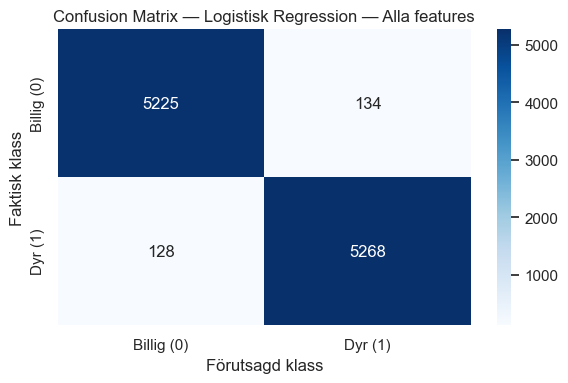


📊 Classification Report — Logistisk Regression — Alla features
──────────────────────────────────────────────────
              precision    recall  f1-score   support

  Billig (0)       0.98      0.97      0.98      5359
     Dyr (1)       0.98      0.98      0.98      5396

    accuracy                           0.98     10755
   macro avg       0.98      0.98      0.98     10755
weighted avg       0.98      0.98      0.98     10755

   Plot sparad till: ../outputs/models/logreg_02_roc_curve.png


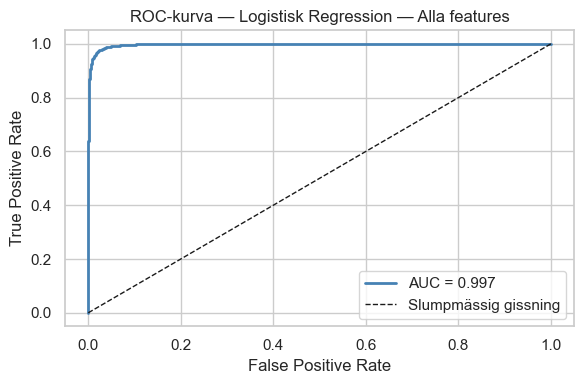

   AUC-värde: 0.997


In [4]:
# ── Förutsägelser ──────────────────────────────────────────────────────────────
y_pred = logreg.predict(X_test)
y_prob = logreg.predict_proba(X_test)[:, 1]

# ── Confusion Matrix ───────────────────────────────────────────────────────────
plot_confusion_matrix(y_test, y_pred, 
                      "Logistisk Regression — Alla features",
                      spara=f"{OUTPUT_DIR}logreg_01_confusion_matrix.png")

# ── Classification Report ──────────────────────────────────────────────────────
print_classification_report(y_test, y_pred, "Logistisk Regression — Alla features")

# ── ROC AUC ───────────────────────────────────────────────────────────────────
auc_alla = plot_roc_curve(y_test, y_prob,
                          "Logistisk Regression — Alla features",
                          spara=f"{OUTPUT_DIR}logreg_02_roc_curve.png")

### Vad ser vi?

**Confusion Matrix:**
- True Negatives (TN) = 5,225: korrekt förutsagda billiga diamanter
- False Positives (FP) = 134: billiga diamanter felaktigt förutsagda som dyra
- False Negatives (FN) = 128: dyra diamanter felaktigt förutsagda som billiga
- True Positives (TP) = 5,268: korrekt förutsagda dyra diamanter
- Totalt fel: 262 av 10,755 (2.4%)

**Classification Report:**
- Accuracy: 98% — modellen gör rätt 98 av 100 gånger
- Precision: 0.98 — när modellen säger "dyr" har den rätt 98% av gångerna
- Recall: 0.98 — modellen hittar 98% av alla dyra diamanter
- F1-score: 0.98 — balansen mellan precision och recall är utmärkt

**ROC AUC = 0.997:**
- Nästan perfekt! Kurvan hugs tätt mot övre vänstra hörnet
- Modellen separerar billiga och dyra diamanter extremt väl

**Hypotes bekräftad:**
Resultaten är imponerande höga — troligtvis pga att x, y, z
är starkt korrelerade med price (0.88-0.89).
Nästa steg: testa modellen UTAN x, y, z.

## 4. Experiment — Vad händer utan x, y, z?

Vi såg i EDA att x, y och z:
- Korrelerar 0.99 med varandra (multikollinearitet)
- Korrelerar 0.88-0.89 med price

De "läcker" indirekt prisinformation till modellen.
Låt oss träna om utan dem och se om accuracy sjunker.

✅ Datasplit: 43,017 träning / 10,755 test
   Target: price_label
   Features: ['carat', 'cut', 'color', 'clarity', 'depth', 'table']
✅ Logistisk Regression tränad
   Plot sparad till: ../outputs/models/logreg_03_confusion_matrix_reducerad.png


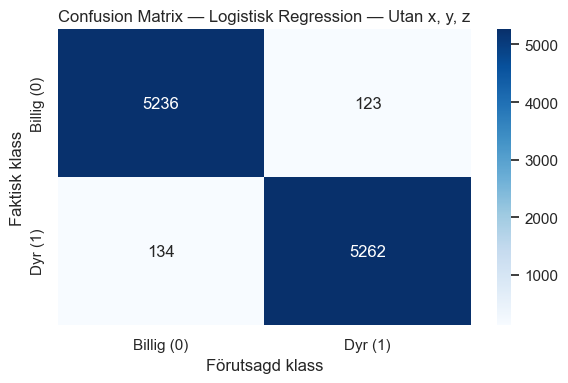


📊 Classification Report — Logistisk Regression — Utan x, y, z
──────────────────────────────────────────────────
              precision    recall  f1-score   support

  Billig (0)       0.98      0.98      0.98      5359
     Dyr (1)       0.98      0.98      0.98      5396

    accuracy                           0.98     10755
   macro avg       0.98      0.98      0.98     10755
weighted avg       0.98      0.98      0.98     10755

   Plot sparad till: ../outputs/models/logreg_04_roc_curve_reducerad.png


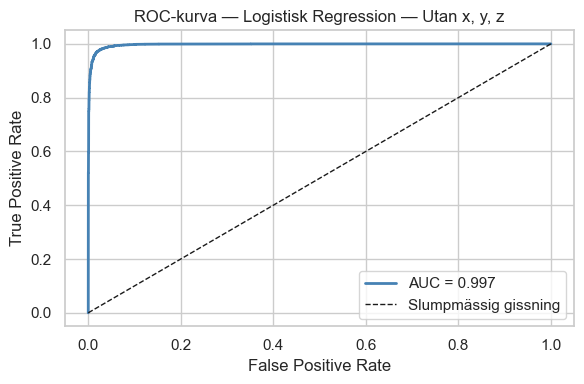

   AUC-värde: 0.997


In [5]:
# ── Förbered data utan x, y, z ────────────────────────────────────────────────
# Vi skapar ett temporärt DataFrame utan x, y, z och kör split_and_scale()
df_red = df[["carat", "cut", "color", "clarity", "depth", "table", "price_label"]].copy()

X_train_r, X_test_r, y_train_r, y_test_r, features_r, scaler_r = split_and_scale(df_red)

# ── Träna modellen ─────────────────────────────────────────────────────────────
logreg_red = train_logistic_regression(X_train_r, y_train_r)

# ── Utvärdera ──────────────────────────────────────────────────────────────────
y_pred_r = logreg_red.predict(X_test_r)
y_prob_r = logreg_red.predict_proba(X_test_r)[:, 1]

plot_confusion_matrix(y_test_r, y_pred_r,
                      "Logistisk Regression — Utan x, y, z",
                      spara=f"{OUTPUT_DIR}logreg_03_confusion_matrix_reducerad.png")

print_classification_report(y_test_r, y_pred_r,
                             "Logistisk Regression — Utan x, y, z")

auc_red = plot_roc_curve(y_test_r, y_prob_r,
                         "Logistisk Regression — Utan x, y, z",
                         spara=f"{OUTPUT_DIR}logreg_04_roc_curve_reducerad.png")

### Vad ser vi? — Utan x, y, z

**Jämförelse: Alla features vs Utan x, y, z**

| Mått | Alla features | Utan x, y, z |
|---|---|---|
| Accuracy | 98% | 98% |
| Precision | 0.98 | 0.98 |
| Recall | 0.98 | 0.98 |
| F1-score | 0.98 | 0.98 |
| AUC | 0.997 | 0.997 |

**Överraskande fynd:**
Modellen presterar identiskt med och utan x, y, z!

**Förklaring:**
- carat (korrelation 0.92 med price) bär nästan all information
- x, y, z korrelerar 0.98 med carat — de tillför ingen ny information
- Logistisk Regression är tillräckligt smart för att "ignorera"
  redundanta features när carat redan förklarar det mesta

**Konsekvens:**
- Vi kan använda 6 features istället för 9 utan prestationsförlust
- Enklare modell = lättare att tolka och förklara
- x, y, z är fysiska mått som i praktiken är samma sak som carat

## 5. Feature Importance

Logistisk Regression ger oss koefficienter för varje feature.
Koefficientens storlek och riktning visar hur mycket varje
feature påverkar förutsägelsen:

- **Positiv koefficient** → ökar sannolikheten för "Dyr"
- **Negativ koefficient** → ökar sannolikheten för "Billig"
- **Stor absolut koefficient** → stor påverkan på modellen

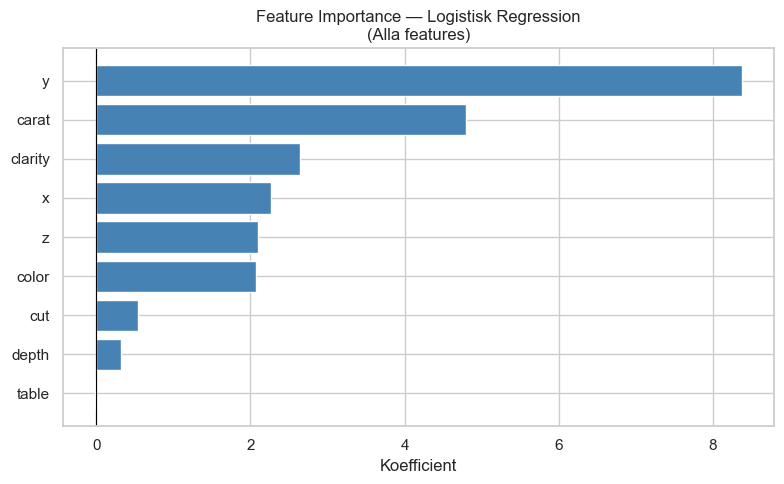


Koefficienter (sorterade efter påverkan):
   + y         : 8.3761
   + carat     : 4.8027
   + clarity   : 2.6447
   + x         : 2.2698
   + z         : 2.0962
   + color     : 2.0783
   + cut       : 0.5371
   + depth     : 0.3174
   - table     : -0.0127


In [6]:
# ── Feature Importance via koefficienter ───────────────────────────────────────
koefficienter = logreg.coef_[0]

importance_df = pd.DataFrame({
    "Feature":      features,
    "Koefficient":  koefficienter,
    "Abs_värde":    abs(koefficienter)
}).sort_values("Abs_värde", ascending=True)

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
colors = ["coral" if k < 0 else "steelblue" for k in importance_df["Koefficient"]]
ax.barh(importance_df["Feature"], importance_df["Koefficient"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Feature Importance — Logistisk Regression\n(Alla features)")
ax.set_xlabel("Koefficient")
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}logreg_05_feature_importance.png",
            dpi=150, bbox_inches="tight")
plt.show()

print("\nKoefficienter (sorterade efter påverkan):")
for _, row in importance_df.iloc[::-1].iterrows():
    riktning = "+" if row["Koefficient"] > 0 else "-"
    print(f"   {riktning} {row['Feature']:<10}: {row['Koefficient']:.4f}")

### Vad ser vi?

**Koefficienter — Logistisk Regression (alla features):**

| Feature | Koefficient | Tolkning |
|---|---|---|
| y | +8.38 | Starkast! Bredd påverkar mest |
| carat | +4.80 | Vikt — som förväntat viktig |
| clarity | +2.64 | Klarhet — positiv påverkan |
| x | +2.27 | Längd — redundant med y och z |
| z | +2.10 | Höjd — redundant med x och y |
| color | +2.08 | Färg — positiv påverkan |
| cut | +0.54 | Slipning — liten påverkan |
| depth | +0.32 | Djup — liten påverkan |
| table | -0.01 | Nästan ingen påverkan alls |

**Överraskande fynd:**
- y (bredd i mm) har högst koefficient — högre än carat!
- Förklaringen: y, x, z delar upp carats förklaringskraft
  sinsemellan — tillsammans är de starkare än carat ensam
- Alla koefficienter är positiva utom table (-0.01)
  som nästan inte påverkar alls

**Viktigt att notera:**
Koefficienterna gäller för SKALADE features (StandardScaler).
Det betyder att vi kan jämföra dem direkt med varandra —
en stor koefficient = stor påverkan, oavsett originalenhet.

**Konsekvens:**
- table kan med fördel tas bort utan påverkan på modellen
- x, y, z sprider ut carats förklaringskraft på tre variabler
- PCA i notebook 05 kommer att hantera detta elegant

## 6. Sammanfattning — Logistisk Regression

Resultat och slutsatser från detta experiment.

In [7]:
# ── Sammanfattning ─────────────────────────────────────────────────────────────
print("=" * 55)
print("   Sammanfattning — Logistisk Regression")
print("=" * 55)

print(f"""
MODELL: Logistisk Regression (baseline)

EXPERIMENT 1 — Alla 9 features:
   Accuracy  : 98%
   AUC       : 0.997
   Fel       : 262 av 10,755 diamanter

EXPERIMENT 2 — Utan x, y, z (6 features):
   Accuracy  : 98%
   AUC       : 0.997
   Fel       : 257 av 10,755 diamanter

SLUTSATSER:
   1. Logistisk Regression presterar utmärkt (98% accuracy)
   2. x, y, z tillför ingen extra information — carat räcker
   3. table har nästan ingen påverkan (-0.01)
   4. Modellen är robust — samma resultat med färre features
   5. AUC 0.997 — nästan perfekt separation av billiga/dyra

NÄSTA STEG:
   Jämför med KNN Classifier i 03_knn_classifier.ipynb
   Kan KNN slå Logistisk Regression?
""")
print("=" * 55)

   Sammanfattning — Logistisk Regression

MODELL: Logistisk Regression (baseline)

EXPERIMENT 1 — Alla 9 features:
   Accuracy  : 98%
   AUC       : 0.997
   Fel       : 262 av 10,755 diamanter

EXPERIMENT 2 — Utan x, y, z (6 features):
   Accuracy  : 98%
   AUC       : 0.997
   Fel       : 257 av 10,755 diamanter

SLUTSATSER:
   1. Logistisk Regression presterar utmärkt (98% accuracy)
   2. x, y, z tillför ingen extra information — carat räcker
   3. table har nästan ingen påverkan (-0.01)
   4. Modellen är robust — samma resultat med färre features
   5. AUC 0.997 — nästan perfekt separation av billiga/dyra

NÄSTA STEG:
   Jämför med KNN Classifier i 03_knn_classifier.ipynb
   Kan KNN slå Logistisk Regression?



## 7. Spara resultat

Resultaten sparas till `outputs/results/results_logreg.json` så att
`06_comparison_story.ipynb` kan ladda dem dynamiskt istället för
att ha hårdkodade värden.

Följande sparas:
- **logreg_alla_features** — accuracy och AUC för modellen med alla 9 features
- **logreg_reducerad** — accuracy och AUC för modellen utan x, y, z

In [8]:
# ── Spara resultat till JSON ───────────────────────────────────────────────────
import json

RESULTS_DIR = "../outputs/results/"
os.makedirs(RESULTS_DIR, exist_ok=True)

acc_alla = accuracy_score(y_test, y_pred)
acc_red  = accuracy_score(y_test_r, y_pred_r)

results = {
    "logreg_alla_features": {
        "accuracy": round(acc_alla, 4),
        "auc":      round(auc_alla, 4),
        "n_features": len(features),
    },
    "logreg_reducerad": {
        "accuracy": round(acc_red, 4),
        "auc":      round(auc_red, 4),
        "n_features": len(features_r),
    },
}

with open(f"{RESULTS_DIR}results_logreg.json", "w") as f:
    json.dump(results, f, indent=2)

print(f"✅ Resultat sparade till {RESULTS_DIR}results_logreg.json")
print(json.dumps(results, indent=2))

✅ Resultat sparade till ../outputs/results/results_logreg.json
{
  "logreg_alla_features": {
    "accuracy": 0.9756,
    "auc": 0.9974,
    "n_features": 9
  },
  "logreg_reducerad": {
    "accuracy": 0.9761,
    "auc": 0.9973,
    "n_features": 6
  }
}
